In [1]:
import pandas as pd
import numpy as np
import requests
import json
from bs4 import BeautifulSoup
import re
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import itertools
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split

In [2]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df_full = df[(df['Date'] > '2022-08-01') & (df['Date'] < '2024-12-31')].reset_index(drop=True)
df_full[['Buy', 'Sell']] = df_full[['Buy', 'Sell']].astype(float)
df_1 = df_full[(df_full['Date'] > '2022-08-01') & (df_full['Date'] < '2024-02-15')].reset_index(drop=True)
df_1[['Buy', 'Sell']] = df_1[['Buy', 'Sell']].astype(float)
df = df_full[(df_full['Date'] > '2022-08-01') & (df_full['Date'] < '2023-10-31')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

df

,Date,Buy,Sell
0,2022-08-02,37.3365,37.7062
1,2022-08-03,37.1939,37.5547
2,2022-08-04,37.2707,37.6434
3,2022-08-05,37.2048,37.5732
4,2022-08-08,37.2963,37.6655
...,...,...,...
320,2023-10-24,38.7905,38.8044
321,2023-10-25,38.6666,38.6731
322,2023-10-26,38.4722,38.4933
323,2023-10-27,38.5290,38.5465


In [3]:
print(len(df), len(df_1), len(df_full))

325 402 630


In [4]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл "data/Eur_Uah.csv" вже існує.


In [5]:
def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')

def optimize_holt_winters(train, test, seasonal_periods_list=None):
    if seasonal_periods_list is None:
        seasonal_periods_list = [5, 10, 20]

    trend_options = ['add', 'mul', None]
    seasonal_options = ['add', 'mul', None]

    best_score = float('inf')
    best_params = None
    best_model = None

    combinations = list(itertools.product(trend_options, seasonal_options, seasonal_periods_list))

    for trend, seasonal, period in combinations:
        if seasonal is None and period is not None:
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = ExponentialSmoothing(
                    train,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=period,
                    initialization_method="estimated").fit()

                pred = model.forecast(len(test))
                rmse = np.sqrt(mean_squared_error(test, pred))

                if rmse < best_score:
                    best_score = rmse
                    best_params = {'trend': trend, 'seasonal': seasonal, 'period': period}
                    best_model = model

        except Exception as e:
            continue

    print(f"Найкращі параметри HW: {best_params} з RMSE: {best_score:.4f}")
    return best_model, best_params, best_score

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"{model_name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    return rmse, mape

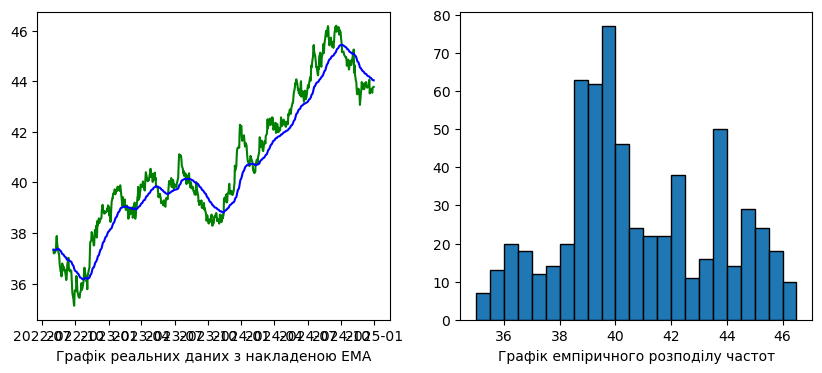

In [6]:
draw_plots(df_full, 'Date', 'Buy')

In [7]:
test_days = 64
train_data = df_full['Buy'].iloc[:-test_days]
test_data = df_full['Buy'].iloc[-test_days:]

hw_model, hw_params, hw_score = optimize_holt_winters(train_data, test_data, seasonal_periods_list=[5, 10, 20])

Найкращі параметри HW: {'trend': None, 'seasonal': 'add', 'period': 5} з RMSE: 1.6014


In [19]:
def prepare_regression_data(series, n_lags=5):
    data = pd.DataFrame(series.copy())
    data.columns = ['y']

    for i in range(1, n_lags + 1):
        data[f'lag_{i}'] = data['y'].shift(i)

    data.dropna(inplace=True)
    X = data.drop('y', axis=1)
    y = data['y']

    return X, y

def optimize_regression(X_train, y_train):
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', Ridge())
    ])
    param_grid = {
        'model__alpha': [0.1, 1.0, 10.0, 50.0],
        'model__solver': ['auto', 'svd', 'cholesky']
    }
    # tscv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(
        pipe,
        param_grid,
        # cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    print(f"Найкращі параметри Регресії: {grid.best_params_}")
    return grid.best_estimator_, grid.score(X_train, y_train)

def recursive_forecast(model, initial_lags, n_steps):
    current_features = list(initial_lags)
    predictions = []

    for _ in range(n_steps):
        X_input = np.array(current_features).reshape(1, -1)
        pred = model.predict(X_input)[0]
        predictions.append(pred)
        current_features = [pred] + current_features[:-1]

    return np.array(predictions)

In [20]:
X, y = prepare_regression_data(df_full['Buy'], n_lags=5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
ridge_model, ridge_score = optimize_regression(X_train, y_train)
ridge_model

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is

Найкращі параметри Регресії: {'model__alpha': 0.1, 'model__solver': 'svd'}


/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None


/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/si

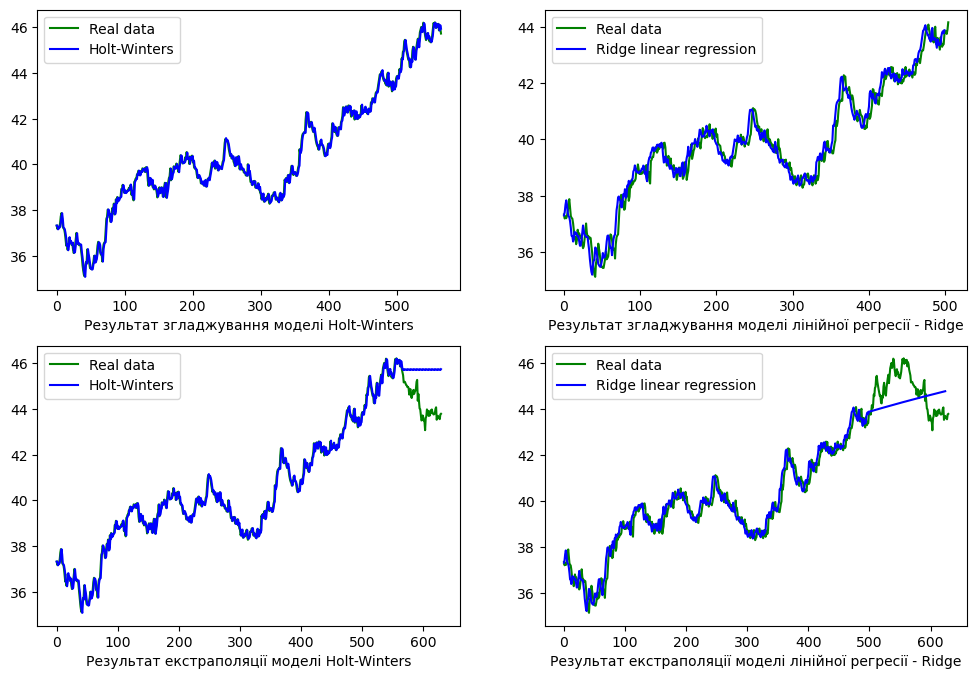


Результати тесту екстраполяції для моделі Holt-Wilters:
RMSE (помилка в гривнях): 1.6014
MAPE (помилка у відсотках): 3.3549%
R2 Score (якість підгонки): -5.5791

Результати тесту екстраполяції для моделі лінійної регресії - Ridge:
RMSE (помилка в гривнях): 1.0953
MAPE (помилка у відсотках): 2.1736%
R2 Score (якість підгонки): -0.7563


In [21]:
hw_smoothing_result = hw_model.fittedvalues
ridge_smoothing_result = ridge_model.predict(X_train)

hw_extrapolate_out = hw_model.forecast(test_days)
full_hw_out = np.concatenate([hw_smoothing_result, hw_extrapolate_out], axis=0)

last_known_lags = X_train.iloc[-1].values
ridge_extrapolate_out = recursive_forecast(ridge_model, last_known_lags, len(y_test))
full_ridge_out = np.concatenate([ridge_smoothing_result, ridge_extrapolate_out], axis=0)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax[0][0].plot(df_full['Buy'].iloc[:-test_days], label='Real data', color='g')
ax[0][0].plot(range(len(hw_smoothing_result)), hw_smoothing_result, label='Holt-Winters', color='b')
ax[0][1].plot(df_full['Buy'].iloc[:-len(X_test)], label='Real data', color='g')
ax[0][1].plot(range(len(ridge_smoothing_result)), ridge_smoothing_result, label='Ridge linear regression', color='b')

ax[1][0].plot(df_full['Buy'], label='Real data', color='g')
ax[1][0].plot(range(len(full_hw_out)), full_hw_out, label='Holt-Winters', color='b')
ax[1][1].plot(df_full['Buy'], label='Real data', color='g')
ax[1][1].plot(range(len(full_ridge_out)), full_ridge_out, label='Ridge linear regression', color='b')
# fig
ax[0][0].set_xlabel('Результат згладжування моделі Holt-Winters')
ax[0][1].set_xlabel('Результат згладжування моделі лінійної регресії - Ridge')
ax[1][0].set_xlabel('Результат екстраполяції моделі Holt-Winters')
ax[1][1].set_xlabel('Результат екстраполяції моделі лінійної регресії - Ridge')
ax[0][0].legend()
ax[0][1].legend()
ax[1][0].legend()
ax[1][1].legend()
plt.show()

rmse_1 = np.sqrt(mean_squared_error(df_full['Buy'].iloc[-test_days:], hw_extrapolate_out))
mape_1 = mean_absolute_percentage_error(df_full['Buy'].iloc[-test_days:], hw_extrapolate_out) * 100
r2_1 = r2_score(df_full['Buy'].iloc[-test_days:], hw_extrapolate_out)

rmse_2 = np.sqrt(mean_squared_error(y_test, ridge_extrapolate_out))
mape_2 = mean_absolute_percentage_error(y_test, ridge_extrapolate_out) * 100
r2_2 = r2_score(y_test, ridge_extrapolate_out)

print(f"\nРезультати тесту екстраполяції для моделі Holt-Wilters:")
print(f"RMSE (помилка в гривнях): {rmse_1:.4f}")
print(f"MAPE (помилка у відсотках): {mape_1:.4f}%")
print(f"R2 Score (якість підгонки): {r2_1:.4f}")

print(f"\nРезультати тесту екстраполяції для моделі лінійної регресії - Ridge:")
print(f"RMSE (помилка в гривнях): {rmse_2:.4f}")
print(f"MAPE (помилка у відсотках): {mape_2:.4f}%")
print(f"R2 Score (якість підгонки): {r2_2:.4f}")